REAL-WORLD DATA PROJECT: DIABETES PREDICTION
HEALTHCARE DOMAIN

Dataset loaded successfully!
Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigree  Age  Outcome  
0             0.627   50        1  
1             0.351   31        0  
2             0.672   32        1  
3             0.167   21        0  
4             2.288   33        1  

EXPLORATORY DATA ANALYSIS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pregnancies 

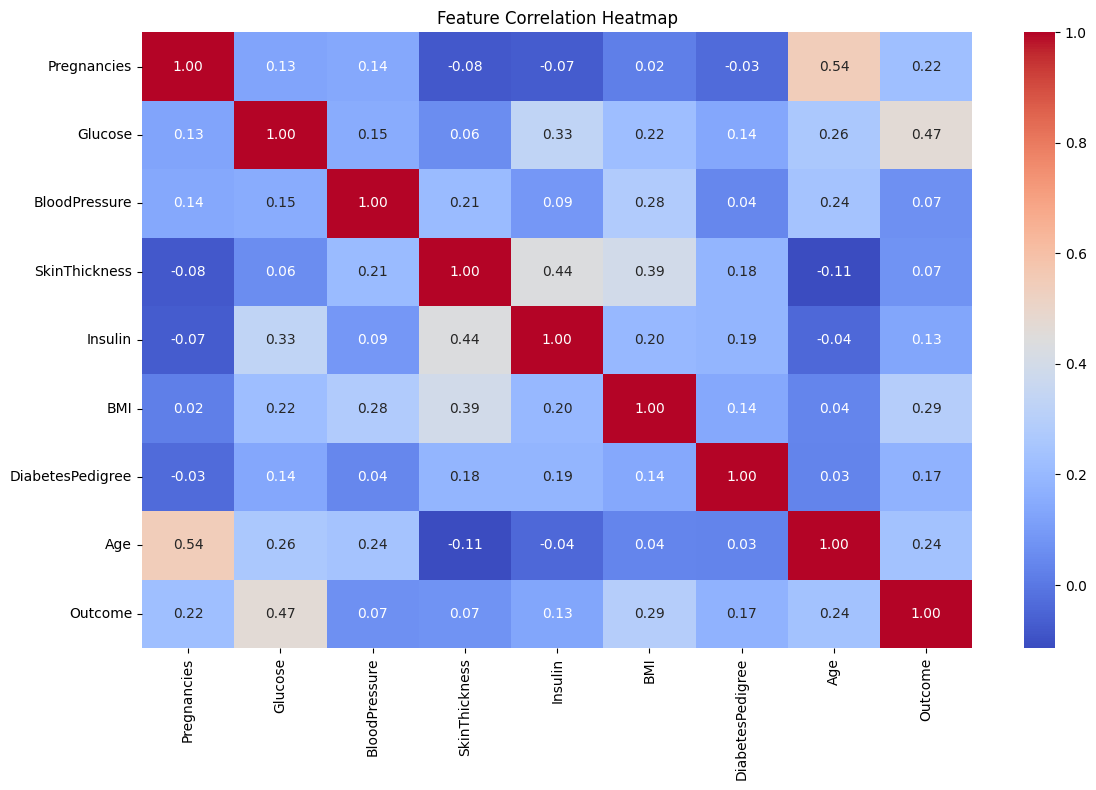

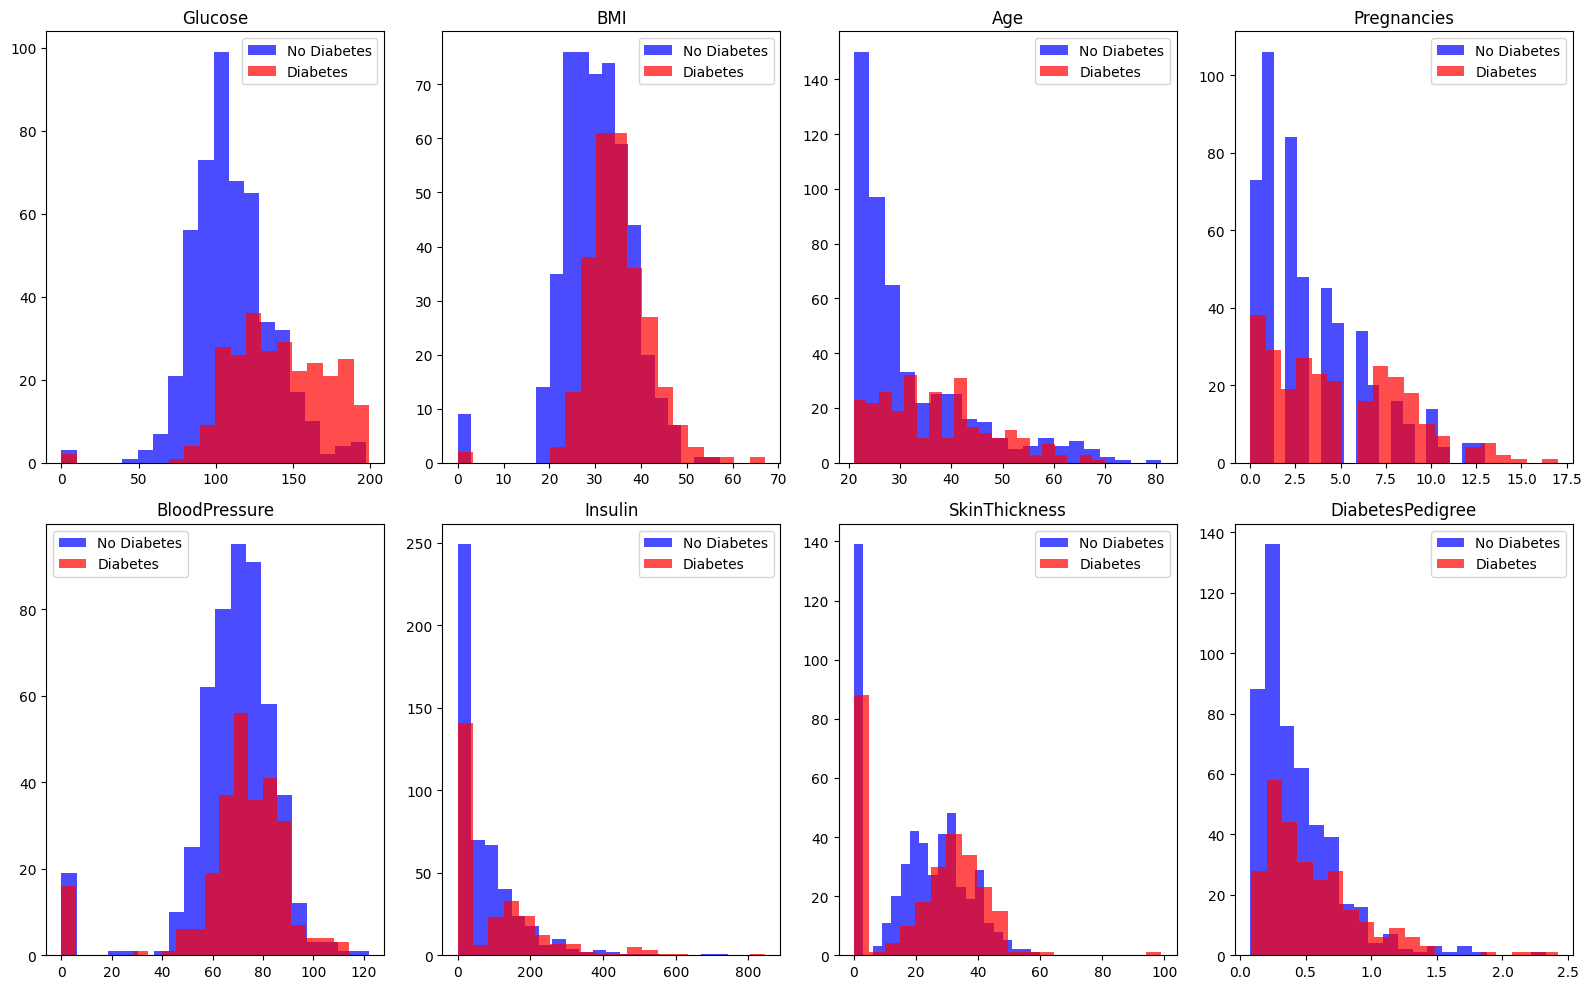


DATA PREPROCESSING
Columns where zero is invalid:
  Glucose: 5 zeros
  BloodPressure: 35 zeros
  SkinThickness: 227 zeros
  Insulin: 374 zeros
  BMI: 11 zeros

Zero values replaced with median values
Training set: 614 samples
Test set: 154 samples

HANDLING CLASS IMBALANCE WITH SMOTE
Before SMOTE - Class distribution:
Outcome
0    400
1    214

After SMOTE - Class distribution:
Outcome
0    400
1    400

MODEL TRAINING AND EVALUATION

Logistic Regression:
  Test Accuracy: 0.7143
  Cross-Validation Accuracy: 0.7387
              precision    recall  f1-score   support

 No Diabetes       0.80      0.74      0.77       100
    Diabetes       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154


Decision Tree:
  Test Accuracy: 0.7208
  Cross-Validation Accuracy: 0.7362
              precision    recall  f1-score   support

 No Diabetes       0.

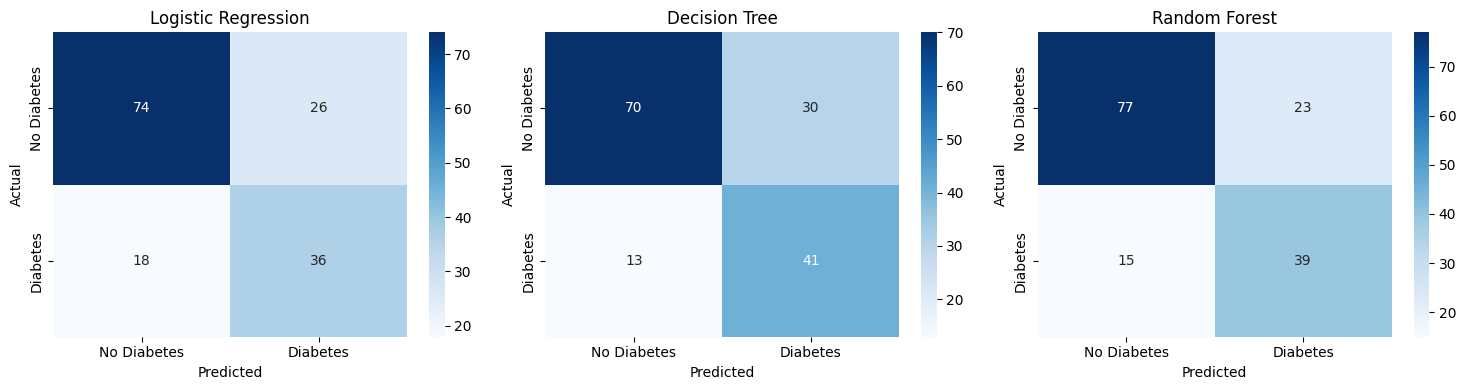


ROC CURVES


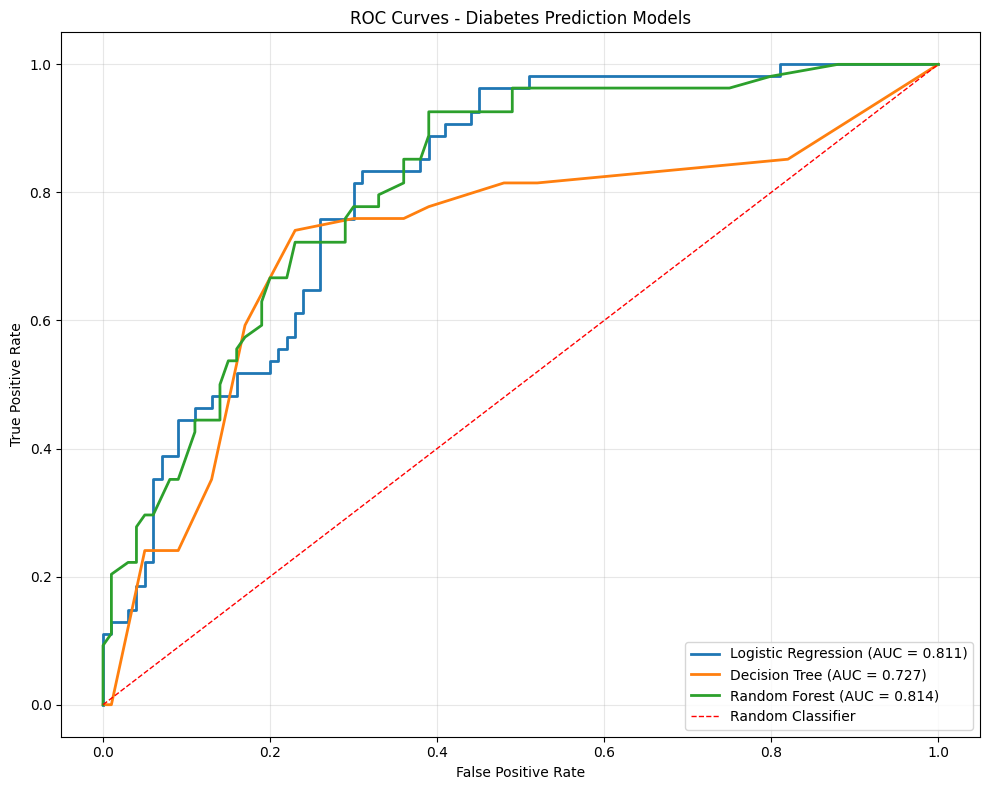


FEATURE IMPORTANCE


/tmp/ipykernel_9382/4177094541.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


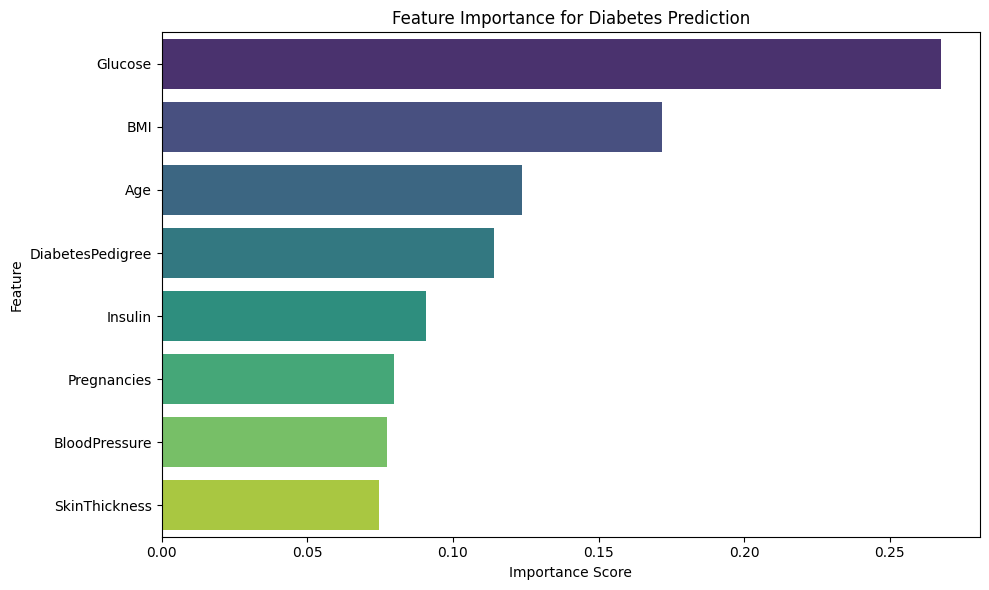


Feature Importance Ranking:
  Glucose: 0.2675
  BMI: 0.1718
  Age: 0.1238
  DiabetesPedigree: 0.1141
  Insulin: 0.0907
  Pregnancies: 0.0798
  BloodPressure: 0.0776
  SkinThickness: 0.0747

KEY FINDINGS & INSIGHTS

1. DATA INSIGHTS
   - Dataset contains 768 patient records
   - 34.9% of patients have diabetes
   - Most important predictors: Glucose, BMI, Age

2. MODEL PERFORMANCE
   - Best Model: Random Forest
   - Best Accuracy: 0.7532 (75.3%)

3. CLINICAL INSIGHTS
   - High Glucose levels are the strongest predictor of diabetes
   - BMI and Age also significantly influence diabetes risk
   - The model can help identify high-risk patients for early intervention

RECOMMENDATIONS

1. FOR HEALTHCARE PROVIDERS
   - Use Glucose, BMI, and Age as primary screening indicators
   - Implement this model as a decision support tool
   - Focus preventive care on patients with high risk scores

2. FOR PATIENTS
   - Maintain healthy BMI levels
   - Regular glucose monitoring for at-risk individuals

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

from imblearn.over_sampling import SMOTE

print("="*60)
print("REAL-WORLD DATA PROJECT: DIABETES PREDICTION")
print("HEALTHCARE DOMAIN")
print("="*60)

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

df = pd.read_csv(url, names=columns)

print("\nDataset loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

print(df.info())
print("\nStatistical Summary:")
print(df.describe())

print("\nTarget Distribution (0=No Diabetes, 1=Diabetes):")
print(df['Outcome'].value_counts())
print(f"Percentage with Diabetes: {df['Outcome'].mean()*100:.2f}%")

print("\nCorrelation with Outcome:")
correlation = df.corr()['Outcome'].sort_values(ascending=False)
print(correlation)

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16,10))
features = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'BloodPressure', 'Insulin', 'SkinThickness', 'DiabetesPedigree']
for i, feature in enumerate(features):
    row, col = i//4, i%4
    axes[row, col].hist(df[df['Outcome']==0][feature], alpha=0.7, label='No Diabetes', bins=20, color='blue')
    axes[row, col].hist(df[df['Outcome']==1][feature], alpha=0.7, label='Diabetes', bins=20, color='red')
    axes[row, col].set_title(feature)
    axes[row, col].legend()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("DATA PREPROCESSING")
print("="*60)

zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Columns where zero is invalid:")
for col in zero_columns:
    zeros = (df[col] == 0).sum()
    print(f"  {col}: {zeros} zeros")

for col in zero_columns:
    median_val = df[df[col] != 0][col].median()
    df[col] = df[col].replace(0, median_val)

print("\nZero values replaced with median values")

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print("\n" + "="*60)
print("HANDLING CLASS IMBALANCE WITH SMOTE")
print("="*60)

print(f"Before SMOTE - Class distribution:")
print(y_train.value_counts().to_string())

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE - Class distribution:")
print(pd.Series(y_train_balanced).value_counts().to_string())

print("\n" + "="*60)
print("MODEL TRAINING AND EVALUATION")
print("="*60)

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=5)
    results.append([name, accuracy, cv_scores.mean()])
    print(f"\n{name}:")
    print(f"  Test Accuracy: {accuracy:.4f}")
    print(f"  Cross-Validation Accuracy: {cv_scores.mean():.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

results_df = pd.DataFrame(results, columns=['Model', 'Test Accuracy', 'CV Accuracy'])
print("\nModel Comparison:")
print(results_df.sort_values('Test Accuracy', ascending=False))

print("\n" + "="*60)
print("CONFUSION MATRICES")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15,4))
models_list = list(models.values())
names_list = list(models.keys())

for i, (model, name) in enumerate(zip(models_list, names_list)):
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ROC CURVES")
print("="*60)

plt.figure(figsize=(10,8))
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    auc = roc_auc_score(y_test, y_pred_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0,1], [0,1], 'r--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Diabetes Prediction Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_balanced, y_train_balanced)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance for Diabetes Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for i, row in feature_importance.iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

print("\n" + "="*60)
print("KEY FINDINGS & INSIGHTS")
print("="*60)

print("\n1. DATA INSIGHTS")
print(f"   - Dataset contains {df.shape[0]} patient records")
print(f"   - {df['Outcome'].mean()*100:.1f}% of patients have diabetes")
print(f"   - Most important predictors: Glucose, BMI, Age")

print("\n2. MODEL PERFORMANCE")
best_model = results_df.loc[results_df['Test Accuracy'].idxmax(), 'Model']
best_accuracy = results_df['Test Accuracy'].max()
print(f"   - Best Model: {best_model}")
print(f"   - Best Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.1f}%)")

print("\n3. CLINICAL INSIGHTS")
print("   - High Glucose levels are the strongest predictor of diabetes")
print("   - BMI and Age also significantly influence diabetes risk")
print("   - The model can help identify high-risk patients for early intervention")

print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)

print("\n1. FOR HEALTHCARE PROVIDERS")
print("   - Use Glucose, BMI, and Age as primary screening indicators")
print("   - Implement this model as a decision support tool")
print("   - Focus preventive care on patients with high risk scores")

print("\n2. FOR PATIENTS")
print("   - Maintain healthy BMI levels")
print("   - Regular glucose monitoring for at-risk individuals")
print("   - Lifestyle modifications for high-risk groups")

print("\n3. FOR MODEL IMPROVEMENT")
print("   - Collect more patient data to improve accuracy")
print("   - Include additional features like family history")
print("   - Validate model on different populations")

print("\n" + "="*60)
print("REAL-WORLD DATA PROJECT COMPLETED")
print("="*60)
